Training set has 637 images.
Test set has 160 images.
Using device: cuda
Starting model training...
  Batch 50/160, Loss: 1.1091
  Batch 100/160, Loss: 1.2459
  Batch 150/160, Loss: 1.1277
Epoch #1 loss: 1.1638
  Batch 50/160, Loss: 1.1013
  Batch 100/160, Loss: 0.3568
  Batch 150/160, Loss: 0.9259
Epoch #2 loss: 0.8748
  Batch 50/160, Loss: 0.7891
  Batch 100/160, Loss: 0.8487
  Batch 150/160, Loss: 0.8965
Epoch #3 loss: 0.7841
  Batch 50/160, Loss: 0.7540
  Batch 100/160, Loss: 0.4024
  Batch 150/160, Loss: 0.5508
Epoch #4 loss: 0.6649
  Batch 50/160, Loss: 0.4707
  Batch 100/160, Loss: 0.4263
  Batch 150/160, Loss: 0.5696
Epoch #5 loss: 0.6322
  Batch 50/160, Loss: 0.5055
  Batch 100/160, Loss: 0.4253
  Batch 150/160, Loss: 0.5030
Epoch #6 loss: 0.6141
  Batch 50/160, Loss: 0.4916
  Batch 100/160, Loss: 0.3773
  Batch 150/160, Loss: 0.7220
Epoch #7 loss: 0.6008
  Batch 50/160, Loss: 0.5425
  Batch 100/160, Loss: 0.7350
  Batch 150/160, Loss: 0.5719
Epoch #8 loss: 0.5953
  Batch 50/1

C:\Users\shiva\AppData\Local\Temp\ipykernel_1128\2262138126.py:254: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(ANALYSIS_FOLD

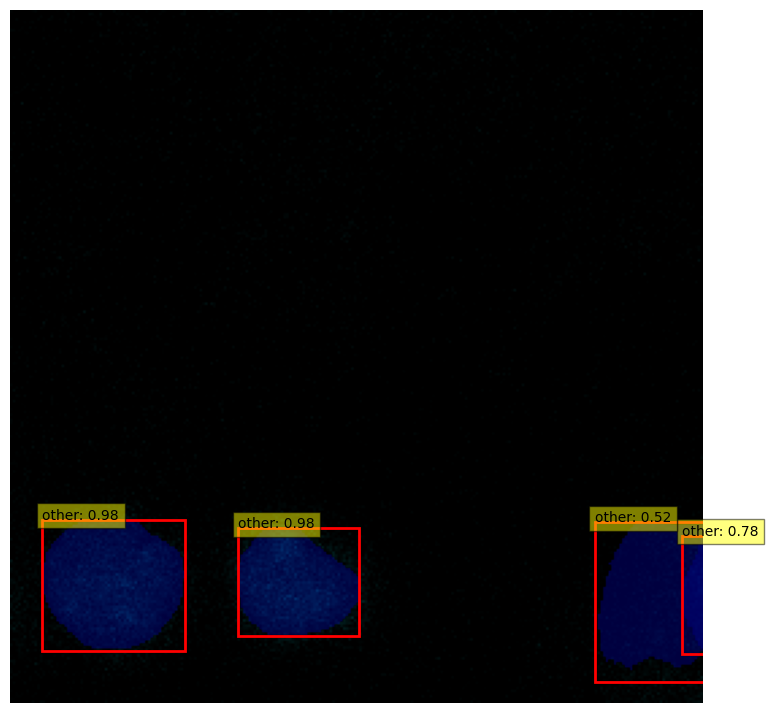

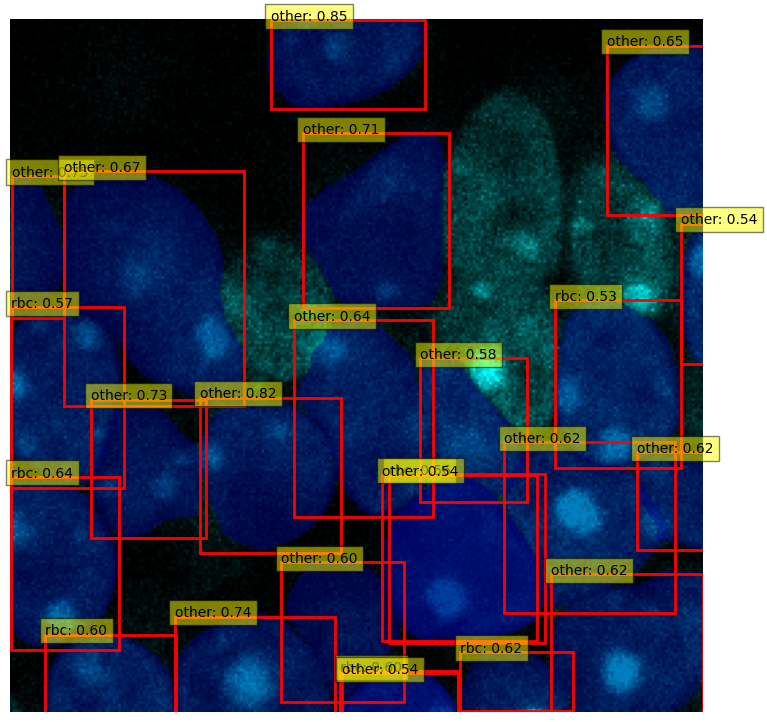

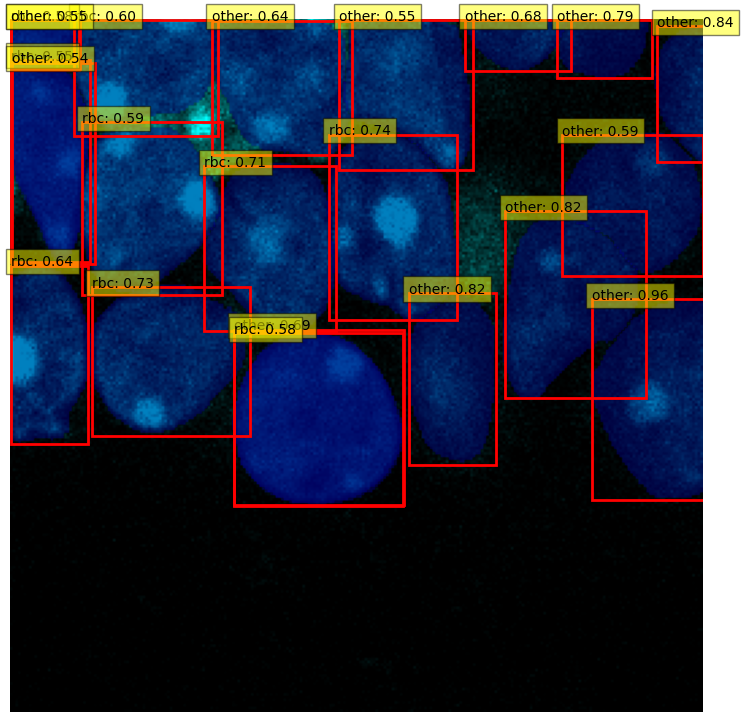

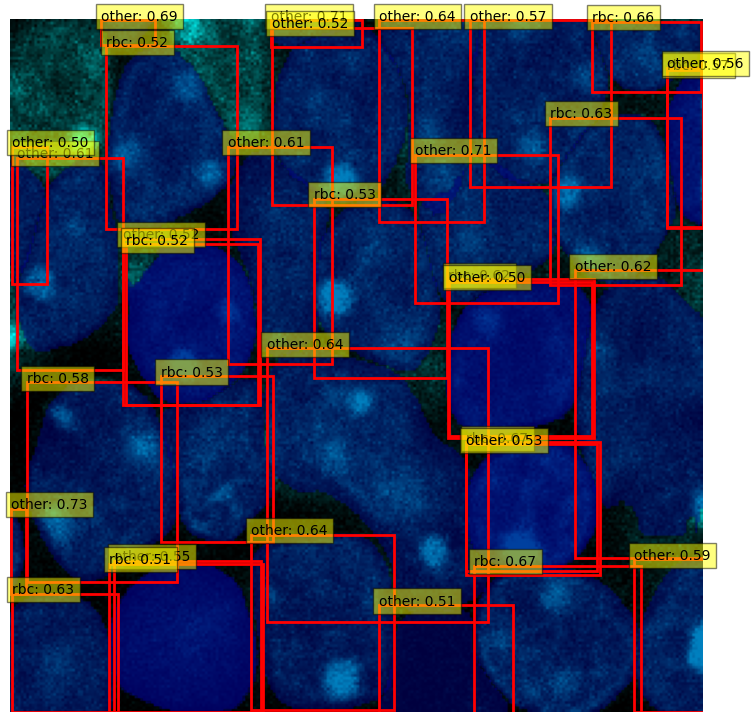

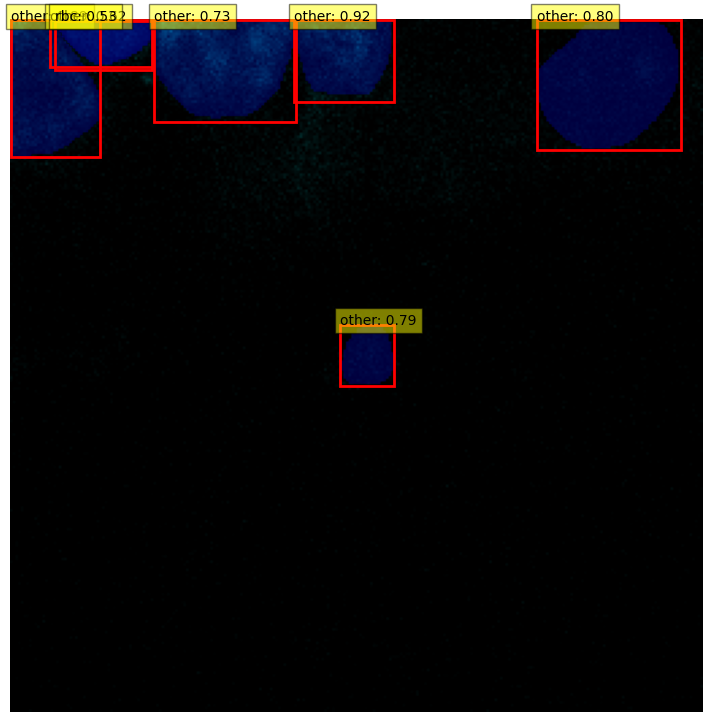


Generating Confusion Matrix...
Confusion matrix, without normalization


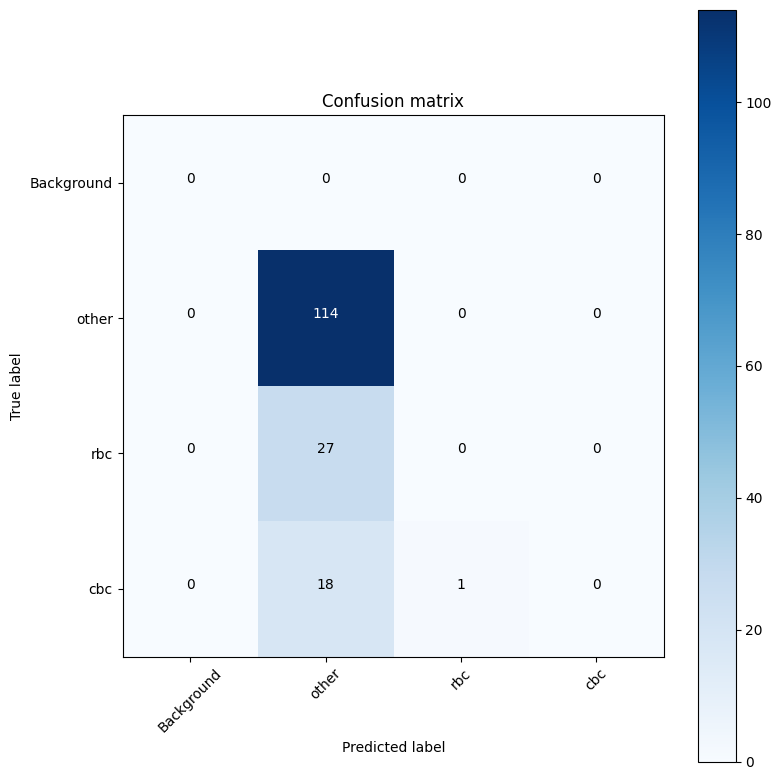

In [1]:
import os
import json
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import itertools
from pycocotools import mask as mask_util # Import the pycocotools mask utility

# --- 1. FILE PATHS AND CONFIGURATION ---
# Define the paths as provided by the user
ANALYSIS_FOLDER = r"C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\analysis"
PROCESSED_DATA_FOLDER = r"C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\processed data"
JSON_FILE_PATH = os.path.join(PROCESSED_DATA_FOLDER, "patches", ".json")
# Corrected the image folder to point to the 'patches' subdirectory
IMAGE_FOLDER = os.path.join(PROCESSED_DATA_FOLDER, "patches")

# Model configuration
# The classes are: 0: background, 1: other (id 0), 2: rbc (id 1), 3: cbc (id 2)
NUM_CLASSES = 4
BATCH_SIZE = 4
NUM_EPOCHS = 10
LEARNING_RATE = 0.005

# --- 2. CUSTOM PYTORCH DATASET ---
# We need a custom dataset to read the images and the COCO-style JSON annotations.

class CellDataset(Dataset):
    def __init__(self, image_info, annotations, image_dir, transforms=None):
        """
        Args:
            image_info (list): List of dictionaries, one for each image.
            annotations (list): List of all annotations from the JSON file.
            image_dir (string): Directory with all the images.
            transforms (callable, optional): Optional transform to be applied on a sample.
        """
        self.image_info = image_info
        self.image_dir = image_dir
        self.transforms = transforms

        # Create a mapping from image_id to annotations
        self.img_to_anns = {}
        for ann in annotations:
            img_id = ann['image_id']
            if img_id not in self.img_to_anns:
                self.img_to_anns[img_id] = []
            self.img_to_anns[img_id].append(ann)

    def __len__(self):
        return len(self.image_info)

    def __getitem__(self, idx):
        # Get image info for the given index
        img_data = self.image_info[idx]
        # The file_name in JSON already contains 'patches\', so we just join with the base processed data folder
        img_path = os.path.join(PROCESSED_DATA_FOLDER, img_data['file_name'])

        # Load image
        try:
            image = Image.open(img_path).convert("RGB")
            width, height = image.size
        except FileNotFoundError:
            print(f"Warning: Image not found at {img_path}. Skipping.")
            return None, None

        # Get all annotations for this image
        img_id = img_data['id']
        anns = self.img_to_anns.get(img_id, [])

        # Extract bounding boxes, labels, and masks
        boxes = []
        labels = []
        masks = []

        for ann in anns:
            # Bounding box [x, y, w, h] -> [x1, y1, x2, y2]
            xmin = ann['bbox'][0]
            ymin = ann['bbox'][1]
            xmax = xmin + ann['bbox'][2]
            ymax = ymin + ann['bbox'][3]

            # --- DATA VALIDATION TO PREVENT RUNTIME ERRORS ---
            # Clamp boxes to image dimensions to prevent out-of-bounds errors
            xmin = max(0, xmin)
            ymin = max(0, ymin)
            xmax = min(width, xmax)
            ymax = min(height, ymax)

            # Check for valid bounding box dimensions after clamping.
            if xmax <= xmin or ymax <= ymin:
                continue

            # Check for valid category_id.
            label = ann['category_id'] + 1
            if label >= NUM_CLASSES:
                continue
            # --- END VALIDATION ---

            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(label)

            # Masks
            # Use pycocotools to decode the RLE segmentation
            mask = mask_util.decode(ann['segmentation'])
            masks.append(mask)

        # If after filtering, there are no valid annotations, we still need to return tensors
        if not boxes:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros(0, dtype=torch.int64)
            masks = torch.zeros((0, height, width), dtype=torch.uint8)
        else:
            # Convert to torch tensors
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            masks = torch.as_tensor(np.array(masks), dtype=torch.uint8)

        # Create the target dictionary
        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["masks"] = masks
        target["image_id"] = torch.tensor([img_id])

        # Apply transformations
        if self.transforms:
            # We need to convert PIL Image to tensor here
            to_tensor = torchvision.transforms.ToTensor()
            image = to_tensor(image)

        return image, target

# --- 3. DATA PREPARATION ---
# Note: Transformation is now handled inside the dataset to ensure consistency
# Load the JSON file
with open(JSON_FILE_PATH, 'r') as f:
    coco_data = json.load(f)

images = coco_data['images']
annotations = coco_data['annotations']

# Split the data into training and testing sets (80/20 split)
train_imgs, test_imgs = train_test_split(images, test_size=0.2, random_state=42)

# Create datasets
train_dataset = CellDataset(train_imgs, annotations, IMAGE_FOLDER, transforms=True)
test_dataset = CellDataset(test_imgs, annotations, IMAGE_FOLDER, transforms=True)

# Custom collate function to handle None values from missing images
def collate_fn(batch):
    batch = list(filter(lambda x: x[0] is not None, batch))
    if not batch:
        return torch.tensor([]), torch.tensor([])
    return tuple(zip(*batch))

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

print(f"Training set has {len(train_dataset)} images.")
print(f"Test set has {len(test_dataset)} images.")

# --- 4. MODEL DEFINITION ---
def get_model_instance_segmentation(num_classes):
    # Load a pre-trained Mask R-CNN model
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")

    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # Replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # Get the number of input features for the mask classifier
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    # Replace the mask predictor with a new one
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)

    return model

# Get the device (GPU if available, otherwise CPU)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

# Instantiate the model
model = get_model_instance_segmentation(NUM_CLASSES)
model.to(device)

# --- 5. TRAINING ---
# Construct an optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=LEARNING_RATE, momentum=0.9, weight_decay=0.0005)

# Learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

print("Starting model training...")

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0
    for i, (images, targets) in enumerate(train_loader):
        if not images: continue # Skip empty batches

        # Filter out targets that have no boxes, as this can cause issues during training
        valid_indices = [idx for idx, t in enumerate(targets) if t['boxes'].shape[0] > 0]
        if not valid_indices:
            continue # Skip batch if no valid targets are left

        images = [images[i] for i in valid_indices]
        targets = [targets[i] for i in valid_indices]

        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        # Check for NaN or inf losses
        if not torch.isfinite(losses):
            print(f"WARNING: non-finite loss at epoch {epoch+1}, batch {i}. Skipping batch.")
            continue

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()
        if i > 0 and i % 50 == 0:
            print(f"  Batch {i}/{len(train_loader)}, Loss: {losses.item():.4f}")


    # Update the learning rate
    lr_scheduler.step()

    print(f"Epoch #{epoch+1} loss: {epoch_loss/len(train_loader):.4f}")

print("Training finished.")

# Save the trained model
torch.save(model.state_dict(), os.path.join(ANALYSIS_FOLDER, 'maskrcnn_model.pth'))
print(f"Model saved to {os.path.join(ANALYSIS_FOLDER, 'maskrcnn_model.pth')}")


# --- 6. EVALUATION AND VISUALIZATION ---
# Load the trained model for inference
model.load_state_dict(torch.load(os.path.join(ANALYSIS_FOLDER, 'maskrcnn_model.pth')))
model.eval()

def visualize_prediction(image_tensor, prediction, threshold=0.5):
    """
    Visualizes the model's prediction on a single image.
    """
    img = image_tensor.permute(1, 2, 0).cpu().numpy()
    fig, ax = plt.subplots(1, figsize=(12, 9))
    ax.imshow(img)

    scores = prediction['scores'].cpu().detach().numpy()
    boxes = prediction['boxes'].cpu().detach().numpy()
    masks = prediction['masks'].cpu().detach().numpy()
    labels = prediction['labels'].cpu().detach().numpy()

    # Define a mapping from label index to name, based on your data creation script
    label_names = {1: 'other', 2: 'rbc', 3: 'cbc'}

    for i in range(len(scores)):
        if scores[i] > threshold:
            # Bounding box
            box = boxes[i]
            rect = patches.Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1], linewidth=2, edgecolor='r', facecolor='none')
            ax.add_patch(rect)

            # Label
            label_idx = labels[i]
            label_name = label_names.get(label_idx, f'Unknown {label_idx}')
            plt.text(box[0], box[1], f'{label_name}: {scores[i]:.2f}', bbox=dict(facecolor='yellow', alpha=0.5))

            # Mask
            mask = masks[i, 0] > 0.5
            ax.imshow(np.ma.masked_where(mask == 0, mask), cmap='jet', alpha=0.5)

    plt.axis('off')
    plt.show()

# Visualize a few predictions from the test set
print("\nVisualizing predictions on test images...")
with torch.no_grad():
    for i in range(min(5, len(test_dataset))): # Visualize first 5 images
        img, _ = test_dataset[i]
        if img is None: continue
        img_tensor = img.to(device)
        prediction = model([img_tensor])
        visualize_prediction(img_tensor, prediction[0])

# --- 7. CONFUSION MATRIX ---
print("\nGenerating Confusion Matrix...")
all_preds = []
all_labels = []

with torch.no_grad():
    for images, targets in test_loader:
        if not images: continue
        images = list(img.to(device) for img in images)

        outputs = model(images)

        for i in range(len(outputs)):
            # Get model predictions
            pred_labels = outputs[i]['labels'].cpu().numpy()
            pred_scores = outputs[i]['scores'].cpu().numpy()

            # Filter predictions by score
            preds = pred_labels[pred_scores > 0.5]

            # Get ground truth labels
            true_labels = targets[i]['labels'].cpu().numpy()

            # For simplicity, we'll take the most frequent prediction if any,
            # and the most frequent ground truth. A more advanced approach
            # would use IoU matching.
            if len(preds) > 0:
                # Use the label of the highest score prediction
                all_preds.append(preds[0])
            else:
                all_preds.append(0) # Predict background if no object detected

            if len(true_labels) > 0:
                all_labels.append(true_labels[0])
            else:
                all_labels.append(0) # Ground truth is background

# Compute confusion matrix
# CORRECTED: Updated labels and class_names for the confusion matrix
cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2, 3])
class_names = ['Background', 'other', 'rbc', 'cbc']

def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

# Plotting the confusion matrix
plt.figure(figsize=(8, 8))
plot_confusion_matrix(cm, class_names)